 ## Sentiment Analysis of Customer Reviews

### Problem Statement:
Build a system that analyzes customer reviews and predicts whether the review sentiment is positive, neutral, or negative based on the review text and rating score.

### Steps to be followed:
1. Importing the required Libraries
2. Loading the dataset
3. Data Preprocessing
4. Checking Null values
5. Data Wrangling (Filling Null values)
6. Data Visualization
7. Label Encoding
8. Feature Selection (x,y)
9. Train-test split
10.  Model Training
11. Model Prediction
12. Accuracy Score
13. Confusion Matrix
14. Classifition Report
15. Training Score 
16. Testing Score
17. GridSearchCV for Hyperparameter Tuning

## Importing Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

## Loading the Dataset 

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\cleaned_reviews.csv")
df

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0
...,...,...,...,...
17335,positive,i love this speaker and love can take it anywh...,30,5.0
17336,positive,i use it in my house easy to connect and loud ...,13,4.0
17337,positive,the bass is good and the battery is amazing mu...,41,5.0
17338,positive,love it,2,5.0


## Data Preprocessing

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  str    
 1   cleaned_review         17337 non-null  str    
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.3 MB


In [4]:
df.describe()

,cleaned_review_length,review_score
count,17340.000000,17340.000000
mean,30.300461,3.649077
std,35.836540,1.673500
min,0.000000,1.000000
25%,9.000000,2.000000
50%,20.000000,5.000000
75%,38.000000,5.000000
max,571.000000,5.000000


In [5]:
df.head()

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [6]:
df.tail()

,sentiments,cleaned_review,cleaned_review_length,review_score
17335,positive,i love this speaker and love can take it anywh...,30,5.0
17336,positive,i use it in my house easy to connect and loud ...,13,4.0
17337,positive,the bass is good and the battery is amazing mu...,41,5.0
17338,positive,love it,2,5.0
17339,neutral,mono speaker,2,5.0


In [7]:
df.columns

Index(['sentiments', 'cleaned_review', 'cleaned_review_length',
       'review_score'],
      dtype='str')

In [8]:
df.count()

sentiments               17340
cleaned_review           17337
cleaned_review_length    17340
review_score             17340
dtype: int64

In [9]:
df.isnull().sum()

sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
dtype: int64

In [10]:
df.isnull().any()

sentiments               False
cleaned_review            True
cleaned_review_length    False
review_score             False
dtype: bool

In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17335    False
17336    False
17337    False
17338     True
17339    False
Length: 17340, dtype: bool

In [12]:
df['cleaned_review_length'] = df['cleaned_review_length'].fillna(df['cleaned_review_length'].median())

In [13]:
df.isnull().sum()

sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
dtype: int64

In [14]:
df['cleaned_review'] = df['cleaned_review'].fillna('cleaned_review')


In [15]:
print(df.isna().sum())

sentiments               0
cleaned_review           0
cleaned_review_length    0
review_score             0
dtype: int64


## Data Visualization / EDA 

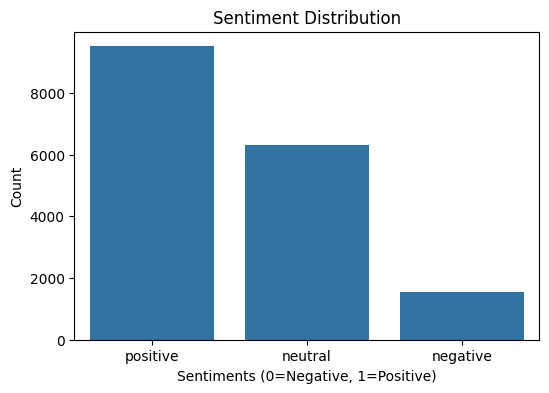

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiments', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiments (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.show()

### The countplot shows the distribution of positive and negative sentiments in the dataset. It helps identify whether the dataset is balanced or contains more reviews of a particular sentiment type.


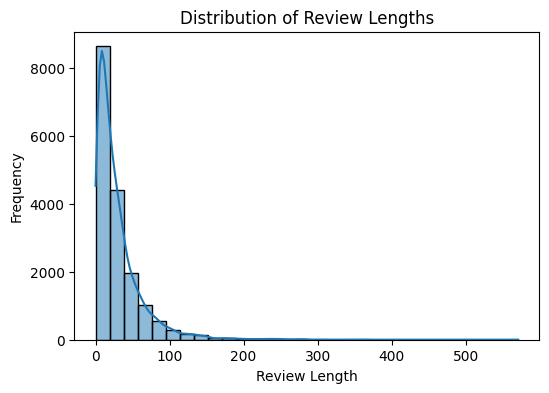

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['cleaned_review_length'], bins=30, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.show()

### The histogram shows the distribution of review lengths in the dataset. It helps understand whether most reviews are short, medium, or long in size.



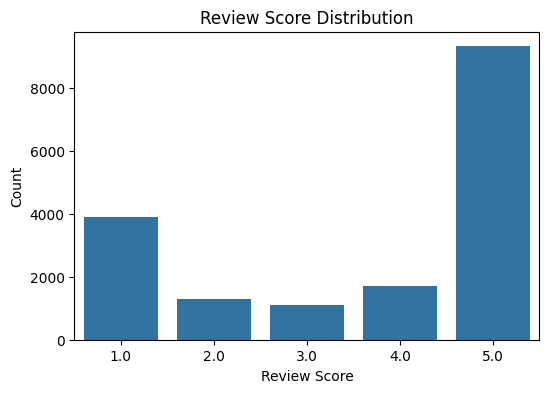

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='review_score', data=df)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

### The countplot shows the distribution of different review scores in the dataset. It helps identify which rating score is given most frequently by customers.


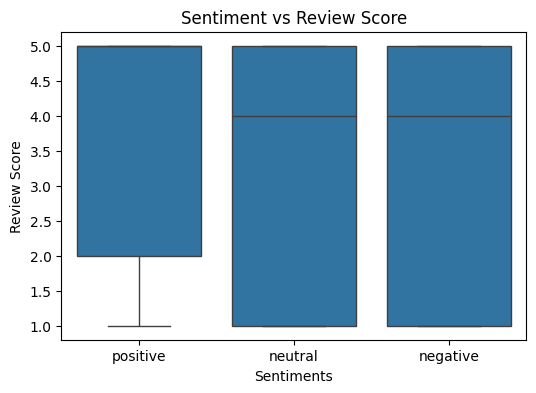

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sentiments', y='review_score', data=df)
plt.title("Sentiment vs Review Score")
plt.xlabel("Sentiments")
plt.ylabel("Review Score")
plt.show()

### The boxplot shows the relationship between sentiments and review scores. It helps analyze how review ratings vary for positive and negative sentiments.


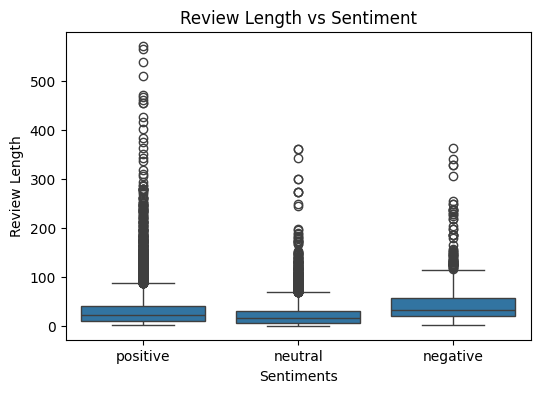

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sentiments', y='cleaned_review_length', data=df)
plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiments")
plt.ylabel("Review Length")
plt.show()

### The boxplot shows the relationship between review length and sentiment. It helps identify whether positive or negative reviews tend to be longer in length.


## Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['sentiments'])

## Feature Selection (x, y)

In [22]:
X = df['cleaned_review']
y = df['sentiments']

## Train-Test Split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Text Vectorization using TF-IDF

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

x_train = tfidf.fit_transform(x_train)
x_test = tfidf.transform(x_test)

## Model Training

In [25]:
model = SVC(kernel='rbf', probability=True)
model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
print(type(x_train))

<class 'scipy.sparse._csr.csr_matrix'>


## Model Prediction 

In [27]:
y_pred = model.predict(x_test)

## Accuracy Score 

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8708189158016147


## Classification Report 

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.90      0.50      0.65       336
     neutral       0.82      0.86      0.84      1253
    positive       0.90      0.94      0.92      1879

    accuracy                           0.87      3468
   macro avg       0.88      0.77      0.80      3468
weighted avg       0.87      0.87      0.87      3468



## Confusion Matrix

In [30]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[ 169  129   38]
 [  14 1082  157]
 [   4  106 1769]]


## Training Score 

In [31]:
model.score(x_train, y_train)

0.9807525951557093

## Testing Score 

In [32]:
model.score(x_test, y_test)

0.8708189158016147

## GridSearchCV for Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear']   # remove rbf
}

svm_model = SVC(probability=True)

grid = GridSearchCV(
    svm_model,
    param_grid,
    cv=3,          # reduce folds
    scoring='accuracy',
    n_jobs=-1      # use all CPU cores
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'kernel': 'linear'}


In [35]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8572664359861591
              precision    recall  f1-score   support

    negative       0.68      0.70      0.69       336
     neutral       0.81      0.84      0.83      1253
    positive       0.92      0.90      0.91      1879

    accuracy                           0.86      3468
   macro avg       0.81      0.81      0.81      3468
weighted avg       0.86      0.86      0.86      3468

[[ 235   83   18]
 [  80 1054  119]
 [  30  165 1684]]


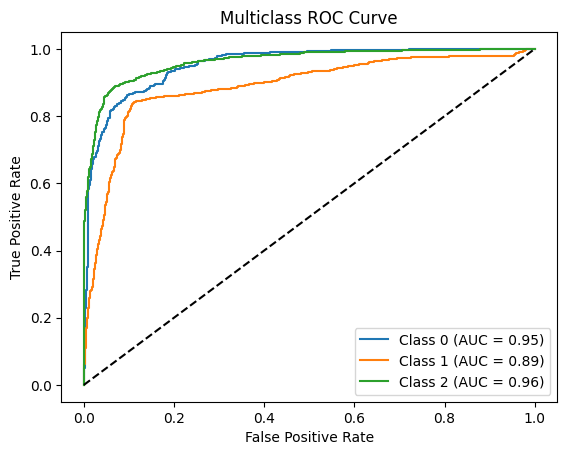

In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert multiclass labels into binary format
y_test_bin = label_binarize(y_test, classes=best_model.classes_)

# Decision scores
y_score = best_model.decision_function(x_test)

# ROC for each class
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend()

plt.show()